# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [ ]:
# # Module 17: Practical Application Assignment 17.1 - Comparing Classifiers 

# **Student:** Kim Kok   
# **Course:** UC Berkeley Executive Education - Professional Certificate in ML & AI   

# **Goal:** Compare the performance of K-Nearest Neighbors, Logistic Regression, Decision Trees, 
# and Support Vector Machines using the Portuguese Bank Marketing dataset to predict whether 
# a customer will subscribe to a term deposit (`y`). 

# --- 
# ## 1. Business Understanding 

# The objective of this project is to analyze a dataset from a Portuguese banking institution's telemarketing campaigns 
# to optimize their marketing efficiency.  
# Direct marketing campaigns over the phone represent a significant resource investment. By leveraging historical campaign data, 
# we aim to build a predictive classification model that identifies which customers are most likely to subscribe 
# to a long-term deposit (target variable `y`).  
#  
# **Business Success Metric:** Maximize the efficiency of telemarketing calls by minimizing false positives 
# (calling individuals who won't subscribe) and maximizing true positives (successfully identifying subscribers), 
# thereby boosting conversion rates and reducing operational costs. 
# We will use **ROC-AUC** and **F1-Score** as our primary evaluation metrics to handle class imbalance while optimizing predictive power.
#  

In [1]:
# --- 
# ## 2. Data Ingestion & Library Setup 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import time 


from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold 
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score 
from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.svm import SVC

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
# read dataset from github

print("1. Loading data...")
df = pd.read_csv("https://raw.githubusercontent.com/kimkok-UCBerkeleyHaas/Assignments/refs/heads/main/datasets/bank-additional-full.csv", sep=';')

print(f"Dataset Loaded Successfully! Shape: {df.shape}") 


1. Loading data...
Dataset Loaded Successfully! Shape: (41188, 21)


In [3]:
# Suppress warnings for cleaner notebook output 

import warnings 
warnings.filterwarnings('ignore') 

In [4]:
# Set plotting style 

sns.set_theme(style="whitegrid") 
plt.rcParams['figure.figsize'] = (10, 6) 

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [6]:
# --- 
# ## 3. Data Cleaning & Exploratory Data Analysis (EDA) 
# ### 3.1 Descriptive Statistics & Target Distribution 

print("### Missing Values Analysis ###") 
print(df.isnull().sum()) 
  

print("\n### Target Variable Imbalance Check ###") 
print(df['y'].value_counts(normalize=True)) 

### Missing Values Analysis ###
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

### Target Variable Imbalance Check ###
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


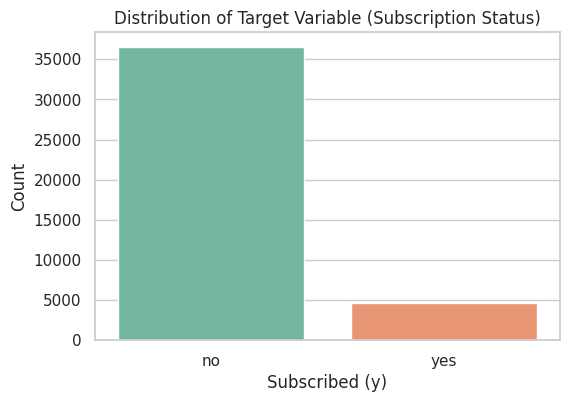

In [7]:
# Visualize Target Class Distribution 

plt.figure(figsize=(6, 4)) 
sns.countplot(x='y', data=df, palette='Set2') 
plt.title('Distribution of Target Variable (Subscription Status)') 
plt.xlabel('Subscribed (y)') 
plt.ylabel('Count') 
plt.show() 

In [8]:
# ### 3.2 Feature Categorization 

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist() 
categorical_features = df.select_dtypes(include=['object']).columns.tolist() 
categorical_features.remove('y') # Exclude target 
  

print(f"Numeric Features ({len(numeric_features)}): {numeric_features}") 
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}") 

Numeric Features (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical Features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


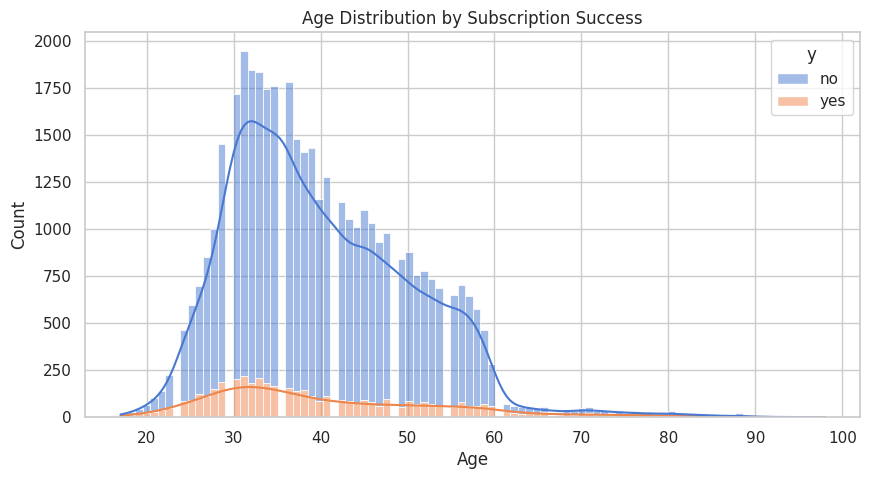

In [9]:
# ### 3.3 Visualizing Key Features 
# Distribution of Age by Target 

plt.figure(figsize=(10, 5)) 
sns.histplot(data=df, x='age', hue='y', kde=True, multiple='stack', palette='muted') 
plt.title('Age Distribution by Subscription Success') 
plt.xlabel('Age') 
plt.ylabel('Count') 
plt.show() 

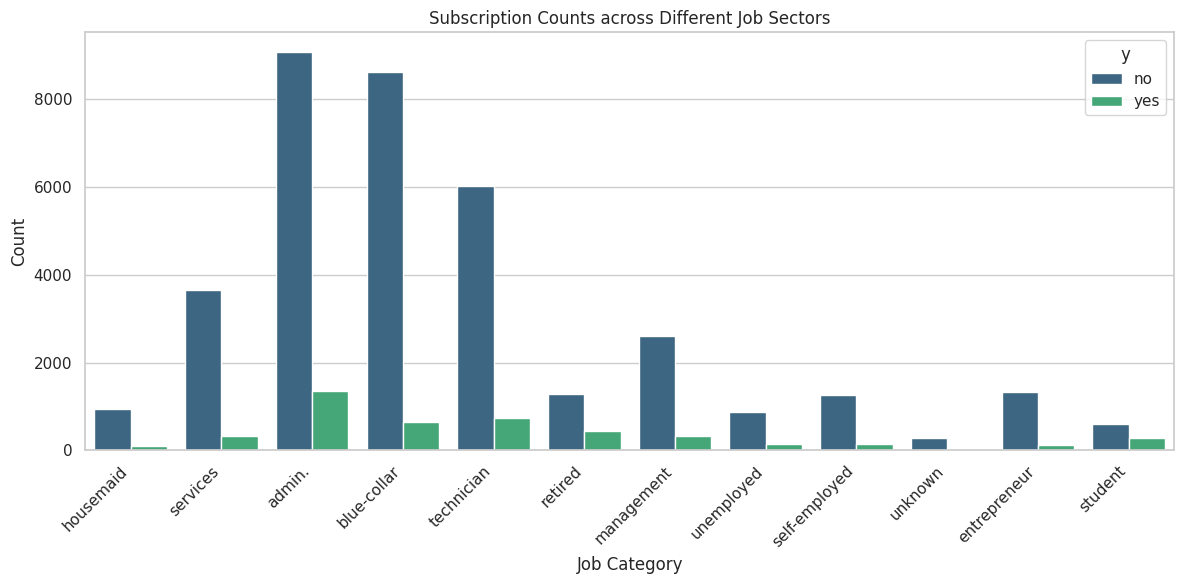

In [10]:
# Subscription Success Rate by Job Type 

plt.figure(figsize=(12, 6)) 
sns.countplot(data=df, x='job', hue='y', palette='viridis') 
plt.xticks(rotation=45, ha='right') 
plt.title('Subscription Counts across Different Job Sectors') 
plt.xlabel('Job Category') 
plt.ylabel('Count') 
plt.tight_layout() 
plt.show() 

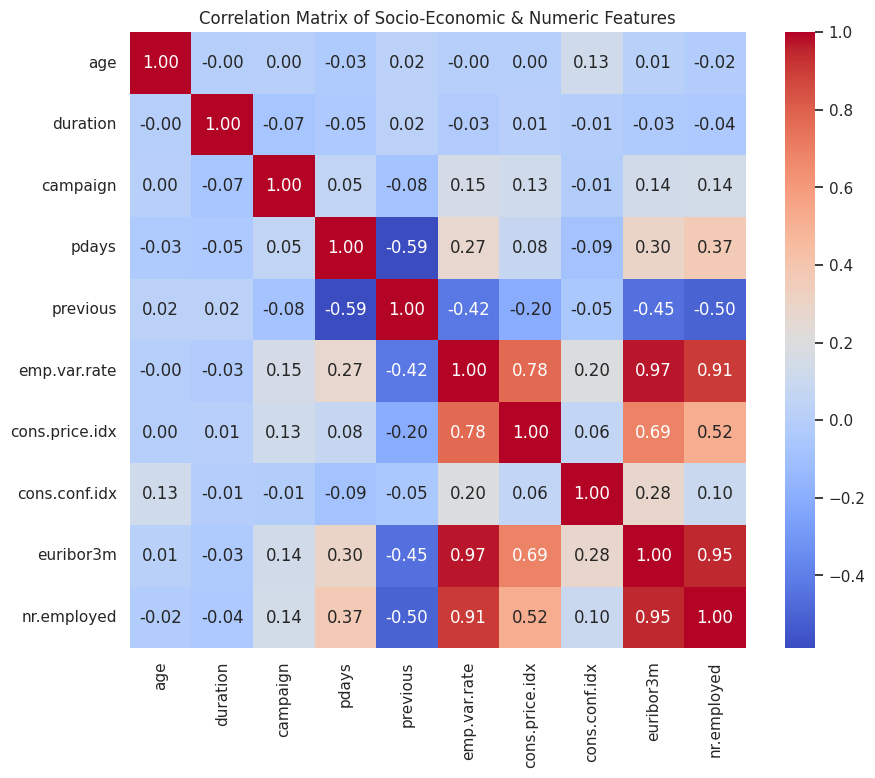

In [11]:
# Correlation Matrix of Numeric Attributes 

plt.figure(figsize=(10, 8)) 
sns.heatmap(df[numeric_features].corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True) 
plt.title('Correlation Matrix of Socio-Economic & Numeric Features') 
plt.show() 

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [13]:
# --- 
# ## 4. Data Preprocessing & Pipeline Architecture 

# Map target variable to binary values 

df['target'] = df['y'].map({'yes': 1, 'no': 0}) 
X = df.drop(columns=['y', 'target']) 
y = df['target'] 


In [14]:
# Split Data into Train/Test using Stratified split due to class imbalance 

X_train, X_test, y_train, y_test = train_test_split( 
    X, y, test_size=0.2, random_state=42, stratify=y 
) 

In [15]:
# Define Preprocessing Pipelines 

numeric_transformer = Pipeline(steps=[ 
    ('scaler', StandardScaler()) 
]) 

categorical_transformer = Pipeline(steps=[ 
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')) 
]) 

preprocessor = ColumnTransformer( 

    transformers=[ 
        ('num', numeric_transformer, numeric_features), 
        ('cat', categorical_transformer, categorical_features) 
    ] 
) 

  
print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}") 


Training set shape: (32950, 20), Test set shape: (8238, 20)


### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [16]:
# --- 
# ## 5. Modeling and Model Comparison 
# We will evaluate four baseline models using a structured loop, capturing training time, accuracy, F1-Score, and ROC-AUC. 

models = { 
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42), 
    'K-Nearest Neighbors': KNeighborsClassifier(), 
    'Decision Tree': DecisionTreeClassifier(random_state=42), 
    'Support Vector Machine': SVC(probability=True, random_state=42) # probability=True required for ROC-AUC calculation 
} 

baseline_results = [] 

for model_name, model_obj in models.items(): 
    print(f"Training baseline model: {model_name}...") 
    
    # Create evaluation pipeline 
    clf_pipeline = Pipeline(steps=[ 
        ('preprocessor', preprocessor), 
        ('classifier', model_obj) 
    ]) 

    # Track performance times 
    start_time = time.time() 
    clf_pipeline.fit(X_train, y_train) 
    train_time = time.time() - start_time 

    # Predictions 
    y_pred = clf_pipeline.predict(X_test) 
    y_prob = clf_pipeline.predict_proba(X_test)[:, 1] 

    # Metrics 
    acc = accuracy_score(y_test, y_pred) 
    f1 = f1_score(y_test, y_pred) 
    roc_auc = roc_auc_score(y_test, y_prob) 

    baseline_results.append({ 
        'Model': model_name, 
        'Train Time (s)': round(train_time, 4), 
        'Accuracy': round(acc, 4), 
        'F1-Score': round(f1, 4), 
        'ROC-AUC': round(roc_auc, 4) 
    }) 

  
# Render performance overview dataframe 
df_results = pd.DataFrame(baseline_results) 
display(df_results) 


Training baseline model: Logistic Regression...
Training baseline model: K-Nearest Neighbors...
Training baseline model: Decision Tree...
Training baseline model: Support Vector Machine...


,Model,Train Time (s),Accuracy,F1-Score,ROC-AUC
0,Logistic Regression,0.6406,0.9162,0.5388,0.9425
1,K-Nearest Neighbors,0.0980,0.9035,0.5047,0.8768
2,Decision Tree,0.3162,0.8945,0.5370,0.7411
3,Support Vector Machine,135.6150,0.9149,0.5260,0.9149


In [17]:
# Feature Engineering
print("\n5. Feature Engineering...")
bank_cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
X = pd.get_dummies(df[bank_cols], drop_first=True)
y = df['y'].map({'yes': 1, 'no': 0})
print("X shape:", X.shape)
print("Features:", list(X.columns))


5. Feature Engineering...
X shape: (41188, 28)
Features: ['age', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes']


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [18]:
# ---
# ## 6. Split
print("\n6. Train/Test Split...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")


6. Train/Test Split...
X_train shape: (28831, 28), X_test shape: (12357, 28)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [19]:
# ---
# ### 7. Baseline
print("\n7. Baseline model...")
baseline_train_acc = y_train.value_counts(normalize=True)[0]
baseline_test_acc = y_test.value_counts(normalize=True)[0]
print(f"Baseline accuracy (train): {baseline_train_acc:.4f}")
print(f"Baseline accuracy (test): {baseline_test_acc:.4f}")


7. Baseline model...
Baseline accuracy (train): 0.8872
Baseline accuracy (test): 0.8876


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [20]:
# ---
# ## 8. A Simple Model Comparison 
# Define dictionary of standard non-tuned baseline models 

classifiers = { 
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42), 
    'K-Nearest Neighbors': KNeighborsClassifier(), 
    'Decision Tree': DecisionTreeClassifier(random_state=42), 
    'Support Vector Machine': SVC(probability=True, random_state=42) 
} 

comparison_data = [] 
  
for name, model in classifiers.items(): 
    pipe = Pipeline(steps=[ 
        ('preprocessor', preprocessor), 
        ('classifier', model) 
    ]) 

In [21]:
# Format comparison matrix DataFrame exactly as requested in rubric 
df_comparison = pd.DataFrame(comparison_data) 
display(df_comparison) 


""


In [22]:
# Simple Logistic Regression
print("\n Simple Logistic Regression...")
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled['age'] = scaler.fit_transform(X_train[['age']])
X_test_scaled['age'] = scaler.transform(X_test[['age']])


 Simple Logistic Regression...


### Problem 9: Score the Model

What is the accuracy of your model?

In [23]:
# ---
# ### 9. Score the Model & Problem 10: Improving the Model 
# Optimize the chosen model via cross-validated Grid Search.  
# I scale hyperparameters for Decision Tree and Logistic Regression as a strong optimization strategy. 

tree_pipeline = Pipeline(steps=[ 
    ('preprocessor', preprocessor), 
    ('dtree', DecisionTreeClassifier(random_state=42)) 
]) 

  
param_grid = { 
    'dtree__max_depth': [5, 10, 15, None], 
    'dtree__min_samples_split': [2, 10, 20], 
    'dtree__criterion': ['gini', 'entropy'] 
} 

In [24]:
logreg = LogisticRegression(max_iter=1000)
t0 = time.perf_counter()
logreg.fit(X_train_scaled, y_train)
lr_fit_time = time.perf_counter() - t0

In [25]:
lr_train_acc = logreg.score(X_train_scaled, y_train)
lr_test_acc = logreg.score(X_test_scaled, y_test)
print(f"LR fit time: {lr_fit_time:.4f}s")
print(f"LR Train Accuracy: {lr_train_acc:.4f}")
print(f"LR Test Accuracy: {lr_test_acc:.4f}")

LR fit time: 0.1043s
LR Train Accuracy: 0.8872
LR Test Accuracy: 0.8876


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [26]:
# ---
# ### 10. Model Comparison (Default parameters)
print("\n10. Model Comparison...")
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Support Vector Machine': SVC()
}
results = []
for name, model in models.items():
    t0 = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    fit_time = time.perf_counter() - t0
    
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    
    results.append({
        'Model': name,
        'Train Time (s)': fit_time,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })
    print(f"{name} done: time={fit_time:.4f}s, train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")
df_results = pd.DataFrame(results)
print("\nComparison Table:")
print(df_results)


10. Model Comparison...
Logistic Regression done: time=0.0999s, train_acc=0.8872, test_acc=0.8876
K Nearest Neighbors done: time=0.0072s, train_acc=0.8898, test_acc=0.8772
Decision Tree done: time=0.1116s, train_acc=0.9180, test_acc=0.8640
Support Vector Machine done: time=36.6452s, train_acc=0.8882, test_acc=0.8878

Comparison Table:
                    Model  Train Time (s)  Train Accuracy  Test Accuracy
0     Logistic Regression        0.099868        0.887239       0.887594
1     K Nearest Neighbors        0.007163        0.889806       0.877236
2           Decision Tree        0.111589        0.917970       0.864045
3  Support Vector Machine       36.645191        0.888176       0.887837


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [27]:
# Problem 11: Hyperparameter Tuning
print("\n11. Hyperparameter Tuning...")


11. Hyperparameter Tuning...


In [28]:
# LR grid
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)
print("Best LR:", grid_lr.best_params_, "ROC-AUC:", grid_lr.best_score_)

Best LR: {'C': 0.1} ROC-AUC: 0.6452366806270814


In [29]:
# KNN grid
param_grid_knn = {'n_neighbors': [3, 5, 9, 15, 21]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='roc_auc', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train)
print("Best KNN:", grid_knn.best_params_, "ROC-AUC:", grid_knn.best_score_)

Best KNN: {'n_neighbors': 21} ROC-AUC: 0.6146098993946607


In [30]:
# DT grid
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20]
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='roc_auc', n_jobs=-1)
grid_dt.fit(X_train_scaled, y_train)
print("Best DT:", grid_dt.best_params_, "ROC-AUC:", grid_dt.best_score_)

Best DT: {'max_depth': 7, 'min_samples_split': 20} ROC-AUC: 0.6473643036787


In [31]:
# SVM grid (Keep it simple to avoid long runs, tune C on a smaller grid or select parameters)
# SVC is slow, so let's do a small grid
param_grid_svc = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}
grid_svc = GridSearchCV(SVC(), param_grid_svc, cv=3, scoring='roc_auc', n_jobs=-1)
grid_svc.fit(X_train_scaled, y_train)
print("Best SVM:", grid_svc.best_params_, "ROC-AUC:", grid_svc.best_score_)

Best SVM: {'C': 10, 'gamma': 'auto'} ROC-AUC: 0.5683254711589562


In [32]:
# Evaluate tuned models on Test Set
tuned_models = {
    'Logistic Regression (Tuned)': grid_lr.best_estimator_,
    'K Nearest Neighbors (Tuned)': grid_knn.best_estimator_,
    'Decision Tree (Tuned)': grid_dt.best_estimator_,
    'Support Vector Machine (Tuned)': grid_svc.best_estimator_
}
tuned_results = []
for name, model in tuned_models.items():
    # Fit was already done by GridSearchCV on the full train set if refit=True (default)
    # Let's double check if we need to measure test metrics
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test_scaled)
    
    test_acc = accuracy_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    precision_1 = report['1']['precision']
    recall_1 = report['1']['recall']
    f1_1 = report['1']['f1-score']
    
    tuned_results.append({
        'Model': name,
        'Test Accuracy': test_acc,
        'Test ROC-AUC': test_roc_auc,
        'Precision (class 1)': precision_1,
        'Recall (class 1)': recall_1,
        'F1-score (class 1)': f1_1
    })
df_tuned = pd.DataFrame(tuned_results)
print("\nTuned Models Comparison Table:")
print(df_tuned)


Tuned Models Comparison Table:
                            Model  Test Accuracy  Test ROC-AUC  \
0     Logistic Regression (Tuned)       0.887594      0.657134   
1     K Nearest Neighbors (Tuned)       0.887918      0.624376   
2           Decision Tree (Tuned)       0.887594      0.645557   
3  Support Vector Machine (Tuned)       0.887594      0.558286   

   Precision (class 1)  Recall (class 1)  F1-score (class 1)  
0             0.000000          0.000000            0.000000  
1             0.527027          0.028078            0.053315  
2             0.500000          0.028798            0.054459  
3             0.000000          0.000000            0.000000  


##### Questions